# BuySense - Random Forest Modelling

This notebook develops and evaluates a Random Forest classifier for predicting online purchase intention.

The objectives are to:

- build a baseline Random Forest model
- evaluate the model using 5-fold stratified cross-validation
- compare normal and balanced class weights
- tune important Random Forest hyperparameters using RandomizedSearchCV
- compare baseline and tuned model performance
- investigate overfitting using training and validation scores
- examine Random Forest feature importance
- compare model performance with and without PageValues
- document findings for final model comparison

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    RandomizedSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    make_scorer
)

pd.set_option("display.max_columns", None)

In [7]:
df = pd.read_csv("../data/raw/online_shoppers_intention.csv")

print(df.shape)
df.head()

(12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [8]:
X = df.drop(columns=["Revenue"])
y = df["Revenue"].astype(int)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [10]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain purchase rate:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest purchase rate:")
print(y_test.value_counts(normalize=True) * 100)

Train shape: (9864, 17)
Test shape: (2466, 17)

Train purchase rate:
Revenue
0    84.529603
1    15.470397
Name: proportion, dtype: float64

Test purchase rate:
Revenue
0    84.509327
1    15.490673
Name: proportion, dtype: float64


In [11]:
def add_engineered_features(data):
    data = data.copy()

    data["TotalPages"] = (
        data["Administrative"]
        + data["Informational"]
        + data["ProductRelated"]
    )

    data["TotalDuration"] = (
        data["Administrative_Duration"]
        + data["Informational_Duration"]
        + data["ProductRelated_Duration"]
    )

    data["AvgDurationPerPage"] = np.where(
        data["TotalPages"] > 0,
        data["TotalDuration"] / data["TotalPages"],
        0
    )

    data["ProductPageShare"] = np.where(
        data["TotalPages"] > 0,
        data["ProductRelated"] / data["TotalPages"],
        0
    )

    data["ProductDurationShare"] = np.where(
        data["TotalDuration"] > 0,
        data["ProductRelated_Duration"] / data["TotalDuration"],
        0
    )

    return data

In [12]:
X_train = add_engineered_features(X_train)
X_test = add_engineered_features(X_test)

In [13]:
engineered_features = [
    "TotalPages",
    "TotalDuration",
    "AvgDurationPerPage",
    "ProductPageShare",
    "ProductDurationShare"
]

print("Missing values:")
print(X_train[engineered_features].isna().sum())

print("\nInfinite values:")
print(np.isinf(X_train[engineered_features]).sum())

Missing values:
TotalPages              0
TotalDuration           0
AvgDurationPerPage      0
ProductPageShare        0
ProductDurationShare    0
dtype: int64

Infinite values:
TotalPages              0
TotalDuration           0
AvgDurationPerPage      0
ProductPageShare        0
ProductDurationShare    0
dtype: int64


In [14]:
categorical_features = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType"
]

boolean_features = ["Weekend"]

numeric_features = [
    col for col in X_train.columns
    if col not in categorical_features + boolean_features
]

In [15]:
print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nBoolean features:")
print(boolean_features)

Numerical features:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'TotalPages', 'TotalDuration', 'AvgDurationPerPage', 'ProductPageShare', 'ProductDurationShare']

Categorical features:
['Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType']

Boolean features:
['Weekend']


In [16]:
preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        ("bool", "passthrough", boolean_features)
    ]
)

In [17]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [18]:
scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(
        precision_score,
        zero_division=0
    ),
    "recall": make_scorer(
        recall_score,
        zero_division=0
    ),
    "f1": make_scorer(
        f1_score,
        zero_division=0
    ),
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

In [19]:
def summarize_cv(model_name, pipeline, X_data, y_data):

    scores = cross_validate(
        pipeline,
        X_data,
        y_data,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    row = {
        "Model": model_name
    }

    for metric in scoring:
        row[f"CV_{metric}_mean"] = scores[
            f"test_{metric}"
        ].mean()

        row[f"CV_{metric}_std"] = scores[
            f"test_{metric}"
        ].std()

    row["Train_F1_mean"] = scores[
        "train_f1"
    ].mean()

    row["Validation_F1_mean"] = scores[
        "test_f1"
    ].mean()

    return row, scores

In [20]:
rf_baseline = Pipeline([
    ("preprocessor", preprocessor_tree),

    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

In [21]:
rf_baseline_row, rf_baseline_scores = summarize_cv(
    "Random Forest - Baseline",
    rf_baseline,
    X_train,
    y_train
)

In [22]:
pd.DataFrame([rf_baseline_row])

,Model,CV_accuracy_mean,CV_accuracy_std,CV_precision_mean,CV_precision_std,CV_recall_mean,CV_recall_std,CV_f1_mean,CV_f1_std,CV_roc_auc_mean,CV_roc_auc_std,CV_pr_auc_mean,CV_pr_auc_std,Train_F1_mean,Validation_F1_mean
0,Random Forest - Baseline,0.900751,0.006302,0.769004,0.025051,0.511786,0.028127,0.614457,0.027821,0.923473,0.005264,0.735803,0.019361,1.0,0.614457


In [23]:
pd.DataFrame([rf_baseline_row])[
    [
        "Model",
        "CV_accuracy_mean",
        "CV_precision_mean",
        "CV_recall_mean",
        "CV_f1_mean",
        "CV_roc_auc_mean",
        "CV_pr_auc_mean",
        "Train_F1_mean",
        "Validation_F1_mean"
    ]
]

,Model,CV_accuracy_mean,CV_precision_mean,CV_recall_mean,CV_f1_mean,CV_roc_auc_mean,CV_pr_auc_mean,Train_F1_mean,Validation_F1_mean
0,Random Forest - Baseline,0.900751,0.769004,0.511786,0.614457,0.923473,0.735803,1.0,0.614457


### Baseline Random Forest Observation

The baseline Random Forest achieved **90.08% mean cross-validation accuracy** and a strong **ROC-AUC of 0.923**, showing good overall ability to separate purchasers from non-purchasers.

The model achieved **precision of 0.769**, meaning most sessions predicted as purchases were correct. However, **recall was lower at 0.512**, so the model identified only about half of the actual purchasers.

The **F1-score was 0.614** and the **PR-AUC was 0.736**, indicating reasonable performance on the minority purchase class.

However, the **training F1-score was 1.00**, while the **validation F1-score was 0.614**. This large gap suggests that the baseline Random Forest is **overfitting** the training data and may need tuning to improve generalization.

## Random Forest with Balanced Class Weights

The baseline Random Forest showed lower recall for the minority purchase class. Therefore, a second Random Forest model is tested using `class_weight="balanced"` to give greater importance to the minority purchase class.

In [24]:
rf_balanced = Pipeline([
    ("preprocessor", preprocessor_tree),

    ("model", RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

In [25]:
rf_balanced_row, rf_balanced_scores = summarize_cv(
    "Random Forest - Balanced",
    rf_balanced,
    X_train,
    y_train
)

In [26]:
pd.DataFrame([rf_balanced_row])[
    [
        "Model",
        "CV_accuracy_mean",
        "CV_precision_mean",
        "CV_recall_mean",
        "CV_f1_mean",
        "CV_roc_auc_mean",
        "CV_pr_auc_mean",
        "Train_F1_mean",
        "Validation_F1_mean"
    ]
]

,Model,CV_accuracy_mean,CV_precision_mean,CV_recall_mean,CV_f1_mean,CV_roc_auc_mean,CV_pr_auc_mean,Train_F1_mean,Validation_F1_mean
0,Random Forest - Balanced,0.894161,0.644982,0.710355,0.675401,0.925779,0.721527,0.997386,0.675401


In [27]:
rf_classweight_compare = pd.DataFrame([
    rf_baseline_row,
    rf_balanced_row
])

rf_classweight_compare[
    [
        "Model",
        "CV_accuracy_mean",
        "CV_precision_mean",
        "CV_recall_mean",
        "CV_f1_mean",
        "CV_roc_auc_mean",
        "CV_pr_auc_mean",
        "Train_F1_mean",
        "Validation_F1_mean"
    ]
]

,Model,CV_accuracy_mean,CV_precision_mean,CV_recall_mean,CV_f1_mean,CV_roc_auc_mean,CV_pr_auc_mean,Train_F1_mean,Validation_F1_mean
0,Random Forest - Baseline,0.900751,0.769004,0.511786,0.614457,0.923473,0.735803,1.000000,0.614457
1,Random Forest - Balanced,0.894161,0.644982,0.710355,0.675401,0.925779,0.721527,0.997386,0.675401


### Balanced Random Forest Observation

Using `class_weight="balanced"` improved the model’s ability to identify actual purchasers.

Compared with the baseline model, **recall increased from 0.512 to 0.710** and the **F1-score improved from 0.614 to 0.675**. This means the balanced model detected a much larger share of the minority Purchase class.

However, **precision decreased from 0.769 to 0.645** and accuracy fell slightly from **90.08% to 89.42%**, showing the expected precision-recall trade-off.

The **ROC-AUC remained strong and improved slightly from 0.923 to 0.926**, while **PR-AUC decreased slightly from 0.736 to 0.722**.

The training F1 remained very high at **0.997**, compared with a validation F1 of **0.675**, so some overfitting is still present.

Overall, balanced class weights improved minority-class recall and F1-score, but at the cost of lower precision and slightly lower PR-AUC.

## Random Forest Hyperparameter Tuning

The baseline and balanced Random Forest models showed strong overall performance, but both still showed signs of overfitting based on the difference between training and validation F1-scores.

Therefore, `RandomizedSearchCV` is used to search for a better combination of Random Forest hyperparameters using 5-fold stratified cross-validation.

The optimization metric is PR-AUC (`average_precision`) because the Purchase class is the minority class and accuracy alone is not sufficient for this imbalanced classification problem.

In [28]:
from sklearn.model_selection import RandomizedSearchCV

In [29]:
rf_for_tuning = Pipeline([
    ("preprocessor", preprocessor_tree),

    ("model", RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

In [30]:
rf_param_dist = {
    "model__n_estimators": [100, 200, 300, 500],

    "model__max_depth": [None, 5, 10, 15, 20],

    "model__min_samples_split": [2, 5, 10, 20],

    "model__min_samples_leaf": [1, 2, 4, 8],

    "model__max_features": ["sqrt", "log2", None],

    "model__class_weight": [None, "balanced"]
}

In [31]:
rf_search = RandomizedSearchCV(
    estimator=rf_for_tuning,
    param_distributions=rf_param_dist,
    n_iter=30,
    scoring="average_precision",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    refit=True
)

In [32]:
rf_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__class_weight': [None, 'balanced'], 'model__max_depth': [None, 5, ...], 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum 

In [33]:
print("Best CV PR-AUC:")
print(rf_search.best_score_)

print("\nBest parameters:")
print(rf_search.best_params_)

Best CV PR-AUC:
0.7502519939910474

Best parameters:
{'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 8, 'model__max_features': None, 'model__max_depth': 5, 'model__class_weight': None}


In [34]:
best_rf = rf_search.best_estimator_

### Random Forest Tuning Result

`RandomizedSearchCV` identified a best cross-validation PR-AUC of **0.7503**.

The best parameter combination was:

- `n_estimators = 300`
- `max_depth = 5`
- `min_samples_split = 5`
- `min_samples_leaf = 8`
- `max_features = None`
- `class_weight = None`

The tuned configuration uses more controlled tree complexity, particularly through `max_depth=5` and `min_samples_leaf=8`. This may help reduce the overfitting observed in the baseline Random Forest.

Interestingly, the best PR-AUC configuration did not use balanced class weights, showing that class weighting does not automatically produce the best overall precision-recall performance.

In [35]:
rf_tuned_row, rf_tuned_scores = summarize_cv(
    "Random Forest - Tuned",
    best_rf,
    X_train,
    y_train
)

In [36]:
pd.DataFrame([rf_tuned_row])[
    [
        "Model",
        "CV_accuracy_mean",
        "CV_precision_mean",
        "CV_recall_mean",
        "CV_f1_mean",
        "CV_roc_auc_mean",
        "CV_pr_auc_mean",
        "Train_F1_mean",
        "Validation_F1_mean"
    ]
]

,Model,CV_accuracy_mean,CV_precision_mean,CV_recall_mean,CV_f1_mean,CV_roc_auc_mean,CV_pr_auc_mean,Train_F1_mean,Validation_F1_mean
0,Random Forest - Tuned,0.904401,0.735965,0.597647,0.658858,0.930106,0.750252,0.708467,0.658858


In [37]:
rf_compare = pd.DataFrame([
    rf_baseline_row,
    rf_balanced_row,
    rf_tuned_row
])

rf_compare[
    [
        "Model",
        "CV_accuracy_mean",
        "CV_precision_mean",
        "CV_recall_mean",
        "CV_f1_mean",
        "CV_roc_auc_mean",
        "CV_pr_auc_mean",
        "Train_F1_mean",
        "Validation_F1_mean"
    ]
]

,Model,CV_accuracy_mean,CV_precision_mean,CV_recall_mean,CV_f1_mean,CV_roc_auc_mean,CV_pr_auc_mean,Train_F1_mean,Validation_F1_mean
0,Random Forest - Baseline,0.900751,0.769004,0.511786,0.614457,0.923473,0.735803,1.000000,0.614457
1,Random Forest - Balanced,0.894161,0.644982,0.710355,0.675401,0.925779,0.721527,0.997386,0.675401
2,Random Forest - Tuned,0.904401,0.735965,0.597647,0.658858,0.930106,0.750252,0.708467,0.658858


### Random Forest Model Comparison

The three Random Forest versions show different strengths.

The **baseline model** achieved **90.08% accuracy**, **0.769 precision**, **0.512 recall**, **0.614 F1-score**, **0.923 ROC-AUC**, and **0.736 PR-AUC**. However, its training F1 was **1.000** compared with validation F1 of **0.614**, indicating strong overfitting.

The **balanced Random Forest** improved minority-class detection. Recall increased to **0.710** and F1-score improved to **0.675**. However, precision decreased to **0.645** and PR-AUC decreased slightly to **0.722**. This shows the expected precision-recall trade-off.

The **tuned Random Forest** achieved the highest **accuracy of 90.44%**, highest **ROC-AUC of 0.930**, and highest **PR-AUC of 0.750**. Its precision was **0.736**, recall was **0.598**, and F1-score was **0.659**.

Importantly, tuning greatly reduced overfitting. The tuned model had a training F1 of **0.708** and validation F1 of **0.659**, which are much closer than in the baseline and balanced models.

Overall, the balanced model achieved the highest recall and F1-score, while the tuned model achieved the strongest ROC-AUC, PR-AUC, accuracy, and much better generalization.

## Random Forest Feature Importance

The tuned Random Forest is fitted on the full training set to examine which transformed input features contributed most to its predictions.

Feature importance shows how strongly the fitted model relied on each feature when making splits. It does not prove that a feature causes purchasing behaviour.

In [38]:
best_rf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['Administrative','Administrative_Duration','Informational',..., 'AvgDurationPerPage','ProductPageShare','ProductDurationShare']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default 

In [39]:
preprocessor = best_rf.named_steps["preprocessor"]
rf_model = best_rf.named_steps["model"]

In [40]:
feature_names = preprocessor.get_feature_names_out()

In [41]:
rf_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

rf_importance.head(20)

,Feature,Importance
8,num__PageValues,0.774030
6,num__BounceRates,0.050209
22,cat__Month_Nov,0.033477
10,num__TotalPages,0.023256
7,num__ExitRates,0.021523
13,num__ProductPageShare,0.015039
0,num__Administrative,0.014485
11,num__TotalDuration,0.012521
5,num__ProductRelated_Duration,0.010805
4,num__ProductRelated,0.008404


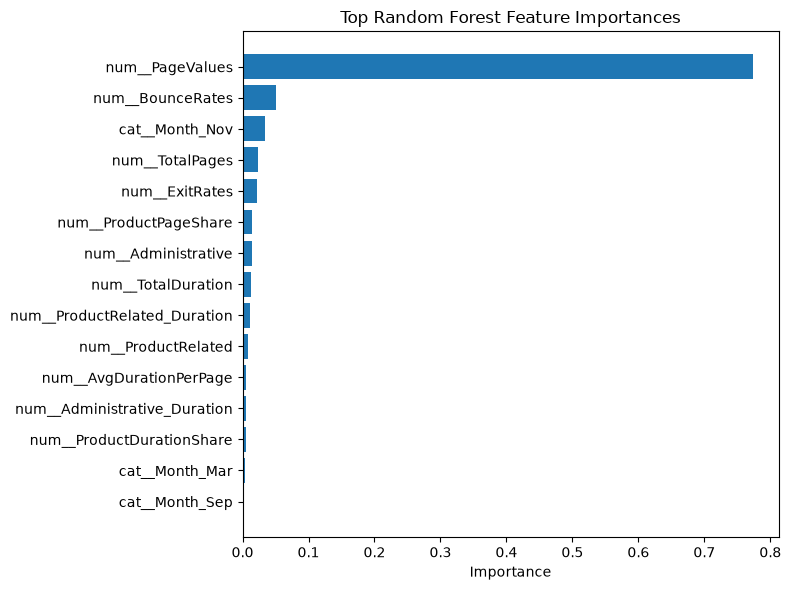

In [42]:
top_rf = (
    rf_importance
    .head(15)
    .sort_values("Importance")
)

plt.figure(figsize=(8, 6))

plt.barh(
    top_rf["Feature"],
    top_rf["Importance"]
)

plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")

plt.tight_layout()
plt.show()

### Random Forest Feature Importance Observation

The tuned Random Forest relied most heavily on **PageValues**, which had a feature importance of approximately **0.774**. This is substantially higher than the importance of all other features.

The next most important features were **BounceRates (0.050)**, **Month_Nov (0.033)**, **TotalPages (0.023)**, and **ExitRates (0.022)**.

Several engineered features, including **ProductPageShare**, **TotalDuration**, **AvgDurationPerPage**, and **ProductDurationShare**, also contributed to the model, although their individual importance values were much smaller.

The very high importance of `PageValues` suggests that the Random Forest depends strongly on this feature. However, feature importance does not prove that `PageValues` causes purchases. It only shows that the fitted model relied heavily on it when making predictions.

Because `PageValues` dominates the model, a controlled experiment with and without `PageValues` is important to determine how much model performance depends on this feature.

## PageValues Sensitivity Experiment

Because `PageValues` showed a strong relationship with `Revenue` during EDA, a controlled experiment is performed to compare Random Forest performance with and without `PageValues`.

This helps determine how dependent the model is on this feature and whether strong performance can still be achieved if `PageValues` is unavailable at prediction time.

In [43]:
X_train_without_pagevalues = X_train.drop(
    columns=["PageValues"]
)

X_test_without_pagevalues = X_test.drop(
    columns=["PageValues"]
)

In [44]:
numeric_features_no_pv = [
    col
    for col in X_train_without_pagevalues.columns
    if col not in categorical_features + boolean_features
]

In [45]:
print(numeric_features_no_pv)

['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'SpecialDay', 'TotalPages', 'TotalDuration', 'AvgDurationPerPage', 'ProductPageShare', 'ProductDurationShare']


In [46]:
preprocessor_tree_no_pv = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            numeric_features_no_pv
        ),

        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),

        (
            "bool",
            "passthrough",
            boolean_features
        )
    ]
)

In [47]:
best_params_clean = {
    key.replace("model__", ""): value
    for key, value in rf_search.best_params_.items()
}

best_params_clean

{'n_estimators': 300,
 'min_samples_split': 5,
 'min_samples_leaf': 8,
 'max_features': None,
 'max_depth': 5,
 'class_weight': None}

In [48]:
rf_no_pv = Pipeline([
    (
        "preprocessor",
        preprocessor_tree_no_pv
    ),

    (
        "model",
        RandomForestClassifier(
            **best_params_clean,
            random_state=42,
            n_jobs=-1
        )
    )
])

In [49]:
rf_with_pv_row, _ = summarize_cv(
    "RF - With PageValues",
    best_rf,
    X_train,
    y_train
)

In [50]:
rf_without_pv_row, _ = summarize_cv(
    "RF - Without PageValues",
    rf_no_pv,
    X_train_without_pagevalues,
    y_train
)

In [51]:
pd.DataFrame([
    rf_with_pv_row,
    rf_without_pv_row
])[
    [
        "Model",
        "CV_accuracy_mean",
        "CV_precision_mean",
        "CV_recall_mean",
        "CV_f1_mean",
        "CV_roc_auc_mean",
        "CV_pr_auc_mean"
    ]
]

,Model,CV_accuracy_mean,CV_precision_mean,CV_recall_mean,CV_f1_mean,CV_roc_auc_mean,CV_pr_auc_mean
0,RF - With PageValues,0.904401,0.735965,0.597647,0.658858,0.930106,0.750252
1,RF - Without PageValues,0.845904,0.586346,0.047185,0.085846,0.773075,0.367051


### PageValues Sensitivity Experiment Observation

Removing `PageValues` caused a major decline in Random Forest performance.

With `PageValues`, the tuned model achieved **90.44% accuracy**, **0.736 precision**, **0.598 recall**, **0.659 F1-score**, **0.930 ROC-AUC**, and **0.750 PR-AUC**.

Without `PageValues`, accuracy fell to **84.59%**, precision to **0.586**, recall dropped sharply to **0.047**, F1-score fell to **0.086**, ROC-AUC decreased to **0.773**, and PR-AUC dropped to **0.367**.

The largest change was in recall, which decreased from **0.598 to 0.047**, meaning the model identified very few actual purchasers once `PageValues` was removed.

This confirms that the Random Forest relies very heavily on `PageValues`. Therefore, the team must carefully verify whether `PageValues` would genuinely be available at the intended prediction time. If it is not available before the purchase outcome is known, using it could create a serious prediction-time leakage or deployment problem.

### Random Forest Final Conclusion

The Random Forest experiments showed that different configurations provide different trade-offs.

The baseline model had strong overall performance but showed clear overfitting. Using balanced class weights improved recall and F1-score for the minority Purchase class, but reduced precision and PR-AUC.

Hyperparameter tuning improved generalization substantially and produced the strongest ROC-AUC and PR-AUC among the Random Forest configurations while reducing the train-validation performance gap.

Feature-importance analysis showed that `PageValues` dominated the model. The controlled sensitivity experiment confirmed this dependence, because performance dropped sharply when `PageValues` was removed.

Therefore, Random Forest is a strong candidate model, but the final use of `PageValues` must be justified based on whether it is available at prediction time.